In [1]:
import sys
import os

# In a Jupyter notebook, __file__ is not defined; use os.getcwd() for the current working directory
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC_PATH = os.path.join(PROJECT_ROOT, 'src')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

os.chdir('../')
from tqdm import tqdm
import pandas as pd
import json
from src.models.config import Config
from src.supervised_runner import SupervisedRunner
from src.semi_supervised_runner import SemiSupervisedRunner
from src.self_supervised_runner import SelfSupervisedRunner
from src.utils.hyperparameter_tuning_utils import set_nested

/Users/parham/Desktop/Projects/amyloid-beta-plaque-classification/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_model(train_type, run_folder_path, load_dataloaders=False):
    if not os.path.exists(os.path.join(run_folder_path, 'config.txt')):
        raise FileNotFoundError(f"Config file not found at {os.path.join(run_folder_path, 'config.txt')}")
    config = Config.from_txt(os.path.join(run_folder_path, 'config.txt'))
    base_params = json.load(open(os.path.join(run_folder_path, 'best_params.json')))
    for key, value in base_params.items():
        set_nested(config, key, value)
    if train_type == 'supervised':
        runner = SupervisedRunner(config, 'single')
    elif train_type == 'semi_supervised':
        runner = SemiSupervisedRunner(config, 'single')
    elif train_type == 'self_supervised':
        runner = SelfSupervisedRunner(config, 'single')
    else:
        raise ValueError(f"Invalid train type: {train_type}")
    model = runner.load_model_from_checkpoint(os.path.join(run_folder_path, 'checkpoints', 'best_model.ckpt'))

    if load_dataloaders:
        if runner._type() == 'supervised':
            labeled_dataloader,_,_= runner.load_dataloaders(runner.labeled_data_df, pd.DataFrame(), pd.DataFrame(), runner.unlabeled_data_df)
            return model, labeled_dataloader
        else:
            labeled_dataloader,_,_,unlabeled_dataloader= runner.load_dataloaders(runner.labeled_data_df, pd.DataFrame(), pd.DataFrame(), runner.unlabeled_data_df)
            return model, (labeled_dataloader, unlabeled_dataloader)
    else:
        return model

In [3]:

# TRAIN_TYPE = 'self_supervised'
# TRAIN_METHOD = 'simclr'
# FEATURE_EXTRACTOR = 'resnet18'

# run_folder_path = './runs/hyperparameter_tuning/' + TRAIN_TYPE + '/' + TRAIN_METHOD + '/' + FEATURE_EXTRACTOR
# model, (labeled_dataloader, unlabeled_dataloader) = load_model(TRAIN_TYPE, run_folder_path, load_dataloaders=True)
# simclr_feature_extractor = model.feature_extractor
# print(f"{TRAIN_TYPE} {TRAIN_METHOD} {FEATURE_EXTRACTOR} feature extractor loaded: ", simclr_feature_extractor)

In [4]:
# TRAIN_TYPE = 'supervised'
# TRAIN_METHOD = ''
# FEATURE_EXTRACTOR = 'resnet18'

# run_folder_path = './runs/hyperparameter_tuning/' + TRAIN_TYPE + '/' + TRAIN_METHOD + '/' + FEATURE_EXTRACTOR
# model = load_model(TRAIN_TYPE, run_folder_path)
# supervised_feature_extractor = model.feature_extractor
# print(f"{TRAIN_TYPE} {TRAIN_METHOD} {FEATURE_EXTRACTOR} feature extractor loaded: ", supervised_feature_extractor)


In [5]:
def extract_features(feature_extractor, dataloader):
    original_extracted_features = []
    augmentations_extracted_features = []
    original_labels = []
    augmentations_labels = []
    device = next(feature_extractor.parameters()).device
    for (_image_path, is_transformed, normalized_transformed_image_tensor, _extra_features, label) in tqdm(dataloader, desc="Extracting features"):
        features = feature_extractor(normalized_transformed_image_tensor.to(device))
        for i in range(len(is_transformed)):
            if is_transformed[i]:
                augmentations_extracted_features.append(features[i].detach().cpu().numpy())
                augmentations_labels.append(label[i].cpu().numpy().item())
            else:
                original_extracted_features.append(features[i].detach().cpu().numpy())
                original_labels.append(label[i].cpu().numpy().item())
    return original_extracted_features, augmentations_extracted_features, original_labels, augmentations_labels

In [6]:
# simclr_original_extracted_features, simclr_augmentations_extracted_features, simclr_original_labels, simclr_augmentations_labels = extract_features(simclr_feature_extractor, labeled_dataloader)
# print(f"Extracted features for {len(simclr_original_extracted_features)} original images each with {len(simclr_original_extracted_features[0])} features")
# print(f"Extracted features for {len(simclr_augmentations_extracted_features)} augmented images each with {len(simclr_augmentations_extracted_features[0])} features")



In [7]:
# supervised_original_extracted_features, supervised_augmentations_extracted_features, supervised_original_labels, supervised_augmentations_labels = extract_features(supervised_feature_extractor, labeled_dataloader)
# print(f"Extracted features for {len(supervised_original_extracted_features)} original images each with {len(supervised_original_extracted_features[0])} features")
# print(f"Extracted features for {len(supervised_augmentations_extracted_features)} augmented images each with {len(supervised_augmentations_extracted_features[0])} features")


In [8]:
# import torch

# def get_model_size_mb(model):
#     param_size = 0
#     buffer_size = 0
#     for param in model.parameters():
#         param_size += param.nelement() * param.element_size()
#     for buf in model.buffers():
#         buffer_size += buf.nelement() * buf.element_size()
#     size_all_mb = (param_size + buffer_size) / 1024**2
#     return size_all_mb

# print("Supervised feature extractor size: {:.2f} MB".format(get_model_size_mb(supervised_feature_extractor)))

# if 'simclr_feature_extractor' in globals():
#     print("SimCLR feature extractor size: {:.2f} MB".format(get_model_size_mb(simclr_feature_extractor)))
# if 'vae_feature_extractor' in globals():
#     print("VAE feature extractor size: {:.2f} MB".format(get_model_size_mb(vae_feature_extractor)))

In [9]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
# from sklearn.metrics import silhouette_score

# def visualize_feature_space(X, y, id_to_name, rng):
#     # Matrix of backbone features and integer labels (same order)
#     n = len(y)

#     # Scale so PCA / t-SNE are not dominated by a few dimensions
#     X_scaled = StandardScaler().fit_transform(X)

#     # Linear 2D view (fast, interpretable variance axes)
#     pca = PCA(n_components=2, random_state=rng)
#     X_pca = pca.fit_transform(X_scaled)

#     # Nonlinear 2D view (often better for class separation at low D)
#     perp = min(30, max(5, (n - 1) // 3))
#     tsne = TSNE(
#         n_components=2,
#         perplexity=perp,
#         n_iter=1000,
#         random_state=rng,
#     )
#     X_tsne = tsne.fit_transform(X_scaled)

#     unique_ids = np.unique(y)
#     fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

#     for ax, Z, title in zip(
#         axes,
#         (X_pca, X_tsne),
#         (
#             f"PCA (var explained: {pca.explained_variance_ratio_.sum():.1%})\nSilhouette score: {silhouette_score(X_pca, y):.3f}",
#             f"t-SNE (perplexity={perp})",
#         ),
#     ):
#         for lid in unique_ids:
#             m = y == lid
#             name = id_to_name.get(int(lid), f"class_{int(lid)}")
#             ax.scatter(Z[m, 0], Z[m, 1], s=10, alpha=0.75, label=name)
#         ax.set_title(title)
#         ax.set_xlabel("Component 1")
#         ax.set_ylabel("Component 2")
#         ax.grid(True, alpha=0.25)

#     handles, labels_leg = axes[0].get_legend_handles_labels()
#     # Single shared legend
#     fig.legend(handles, labels_leg, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
#     plt.suptitle(f"Labeled feature embeddings (n={n}, dim={X.shape[1]})", y=1.02)
#     plt.tight_layout()
#     plt.show()

In [16]:

id_to_name = {"0": "Diffuse",
    "1": "Cored",
    "2": "Compact",
    "3": "Coarse",
    "4": "CAA",
    "5": "Subpial",
    "6": "OtherAB",
    "7": "UndefAB",
    "8": "NonAB"}

In [11]:
# X = np.stack(simclr_original_extracted_features+simclr_augmentations_extracted_features, axis=0)
# y = np.array(simclr_original_labels+simclr_augmentations_labels, dtype=np.int64)
# visualize_feature_space(X, y, id_to_name, config.general_config.system.random_seed)
# print(f"Overall silhouette score: {silhouette_score(X, y): .3f}")


In [12]:
# X = np.stack(supervised_original_extracted_features+supervised_augmentations_extracted_features, axis=0)
# y = np.array(supervised_original_labels+supervised_augmentations_labels, dtype=np.int64)
# visualize_feature_space(X, y, id_to_name, config.general_config.system.random_seed)
# print(f"Overall silhouette score: {silhouette_score(X, y): .3f}")

Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.93it/s]
Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00, 10.53it/s]
Seed set to 44


...

Extracting features: 100%|██████████| 37/37 [00:07<00:00,  5.27it/s]
Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.85it/s]
Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.72it/s]


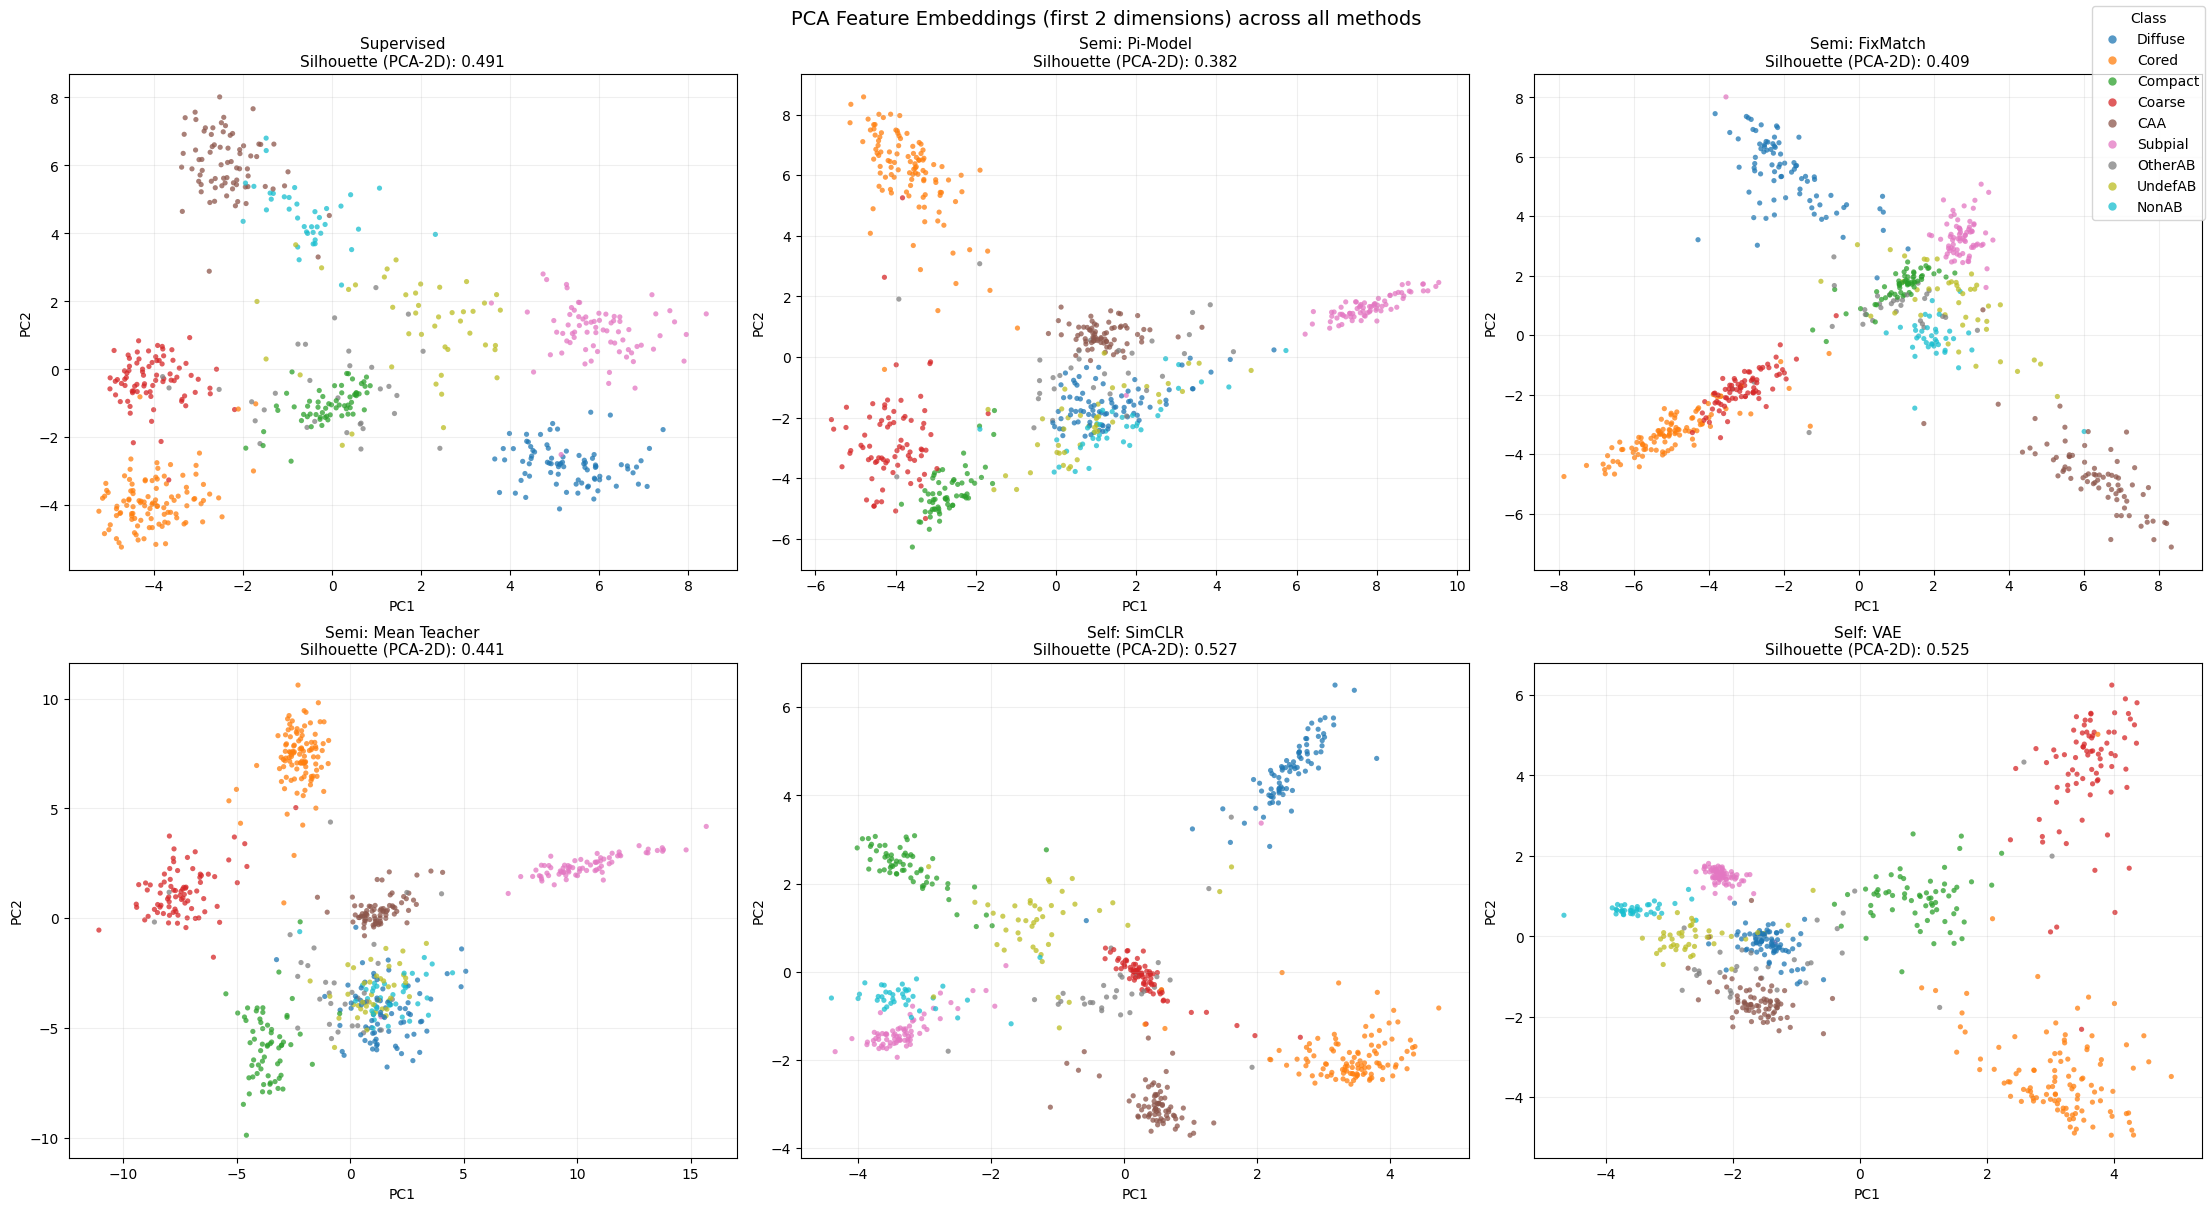

Silhouette scores (PCA 2D):
  Supervised: 0.491
  Semi: Pi-Model: 0.382
  Semi: FixMatch: 0.409
  Semi: Mean Teacher: 0.441
  Self: SimCLR: 0.527
  Self: VAE: 0.525


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Assumes load_model(...) and extract_features(...) are already defined in earlier cells.
METHOD_SPECS = [
    ("supervised", "", "Supervised"),
    ("semi_supervised", "pi_model", "Semi: Pi-Model"),
    ("semi_supervised", "fixmatch", "Semi: FixMatch"),
    ("semi_supervised", "mean_teacher", "Semi: Mean Teacher"),
    ("self_supervised", "simclr", "Self: SimCLR"),
    ("self_supervised", "vae", "Self: VAE"),
]
FEATURE_EXTRACTOR = "resnet18"


def _build_run_path(train_type, train_method, feature_extractor):
    base = f"./runs/hyperparameter_tuning/{train_type}"
    if train_type == "supervised":
        return f"{base}/{feature_extractor}"
    return f"{base}/{train_method}/{feature_extractor}"


def _safe_silhouette(X_2d, y):
    classes = np.unique(y)
    if len(classes) < 2:
        return np.nan
    return silhouette_score(X_2d, y)


fig, axes = plt.subplots(2, 3, figsize=(22, 12), constrained_layout=True)
axes = axes.flatten()

scores = {}
for ax, (train_type, train_method, label) in zip(axes, METHOD_SPECS):
    run_folder_path = _build_run_path(train_type, train_method, FEATURE_EXTRACTOR)

    loaded = load_model(train_type, run_folder_path, load_dataloaders=True)
    if train_type == "supervised":
        model, labeled_dataloader = loaded
    else:
        model, (labeled_dataloader, _unlabeled_dataloader) = loaded

    feature_extractor = model.feature_extractor.eval()
    original_features, _aug_features, original_labels, _aug_labels = extract_features(feature_extractor, labeled_dataloader)

    X = np.asarray(original_features)
    y = np.asarray(original_labels)

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2, random_state=44).fit_transform(X_scaled)

    s = _safe_silhouette(X_pca, y)
    scores[label] = s

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y,
        cmap="tab10",
        s=14,
        alpha=0.75,
        linewidths=0,
    )
    score_text = "nan" if np.isnan(s) else f"{s:.3f}"
    ax.set_title(f"{label}\nSilhouette (PCA-2D): {score_text}", fontsize=11)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.2)

# Hide unused axes (if any)
for ax in axes[len(METHOD_SPECS):]:
    ax.axis("off")

fig.suptitle("PCA Feature Embeddings (first 2 dimensions) across all methods", fontsize=14)

# Shared legend by class ids
handles, _ = scatter.legend_elements(prop="colors")
fig.legend(handles, [id_to_name[str(i)] for i in sorted(np.unique(y))], title="Class", loc="upper right")
plt.savefig("feature_space_pca.pdf")
plt.show()

print("Silhouette scores (PCA 2D):")
for k, v in scores.items():
    print(f"  {k}: {('nan' if np.isnan(v) else f'{v:.3f}')}" )

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

METHOD_SPECS = [
    ("supervised", "", "Supervised"),
    ("semi_supervised", "pi_model", "Semi: Pi-Model"),
    ("semi_supervised", "fixmatch", "Semi: FixMatch"),
    ("semi_supervised", "mean_teacher", "Semi: Mean Teacher"),
    ("self_supervised", "simclr", "Self: SimCLR"),
    ("self_supervised", "vae", "Self: VAE"),
]
FEATURE_EXTRACTOR = "resnet18"


def _build_run_path(train_type, train_method, feature_extractor):
    base = f"./runs/hyperparameter_tuning/{train_type}"
    if train_type == "supervised":
        return f"{base}/{feature_extractor}"
    return f"{base}/{train_method}/{feature_extractor}"


def _safe_silhouette(X, y):
    # silhouette_score requires at least 2 classes.
    if len(np.unique(y)) < 2:
        return np.nan
    return silhouette_score(X, y)


rows = []
for train_type, train_method, model_label in METHOD_SPECS:
    run_folder_path = _build_run_path(train_type, train_method, FEATURE_EXTRACTOR)

    loaded = load_model(train_type, run_folder_path, load_dataloaders=True)
    if train_type == "supervised":
        model, labeled_dataloader = loaded
    else:
        model, (labeled_dataloader, _unlabeled_dataloader) = loaded

    feature_extractor = model.feature_extractor.eval()
    original_features, _aug_features, original_labels, _aug_labels = extract_features(feature_extractor, labeled_dataloader)

    X = np.asarray(original_features)
    y = np.asarray(original_labels)

    # Scale once for both comparisons.
    X_scaled = StandardScaler().fit_transform(X)
    X_pca2 = PCA(n_components=2, random_state=44).fit_transform(X_scaled)

    sil_pca2 = _safe_silhouette(X_pca2, y)
    sil_all = _safe_silhouette(X_scaled, y)

    rows.append(
        {
            "model": model_label,
            "silhouette_pca2": sil_pca2,
            "silhouette_all_dims": sil_all,
            "feature_dim": X.shape[1],
            "n_samples": X.shape[0],
        }
    )

silhouette_df = pd.DataFrame(rows).sort_values("silhouette_all_dims", ascending=False).reset_index(drop=True)

# Rounded view for easier visual comparison.
display_df = silhouette_df.copy()
display_df["silhouette_pca2"] = display_df["silhouette_pca2"].round(3)
display_df["silhouette_all_dims"] = display_df["silhouette_all_dims"].round(3)

display(display_df)

# Optional CSV export if needed later.
# display_df.to_csv("notebooks/feature_space_silhouette_comparison.csv", index=False)

Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.97it/s]
Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.72it/s]
Seed set to 44


...

Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.77it/s]
Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.60it/s]


,model,silhouette_pca2,silhouette_all_dims,feature_dim,n_samples
0,Self: SimCLR,0.527,0.697,32,589
1,Self: VAE,0.525,0.637,32,589
2,Semi: Mean Teacher,0.441,0.636,128,589
3,Semi: FixMatch,0.409,0.608,64,589
4,Semi: Pi-Model,0.382,0.575,64,589
5,Supervised,0.491,0.558,64,589


In [18]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.metrics import silhouette_score

# METHOD_SPECS = [
#     ("supervised", "", "Supervised"),
#     ("semi_supervised", "pi_model", "Semi: Pi-Model"),
#     ("semi_supervised", "fixmatch", "Semi: FixMatch"),
#     ("semi_supervised", "mean_teacher", "Semi: Mean Teacher"),
#     ("self_supervised", "simclr", "Self: SimCLR"),
#     ("self_supervised", "vae", "Self: VAE"),
# ]
# FEATURE_EXTRACTOR = "resnet18"


# def _build_run_path(train_type, train_method, feature_extractor):
#     base = f"./runs/hyperparameter_tuning/{train_type}"
#     if train_type == "supervised":
#         return f"{base}/{feature_extractor}"
#     return f"{base}/{train_method}/{feature_extractor}"


# def _safe_silhouette(X, y):
#     # silhouette_score requires at least 2 classes.
#     if len(np.unique(y)) < 2:
#         return np.nan
#     return silhouette_score(X, y)


# rows = []
# for train_type, train_method, model_label in METHOD_SPECS:
#     run_folder_path = _build_run_path(train_type, train_method, FEATURE_EXTRACTOR)

#     loaded = load_model(train_type, run_folder_path, load_dataloaders=True)
#     if train_type == "supervised":
#         model, labeled_dataloader = loaded
#     else:
#         model, (labeled_dataloader, _unlabeled_dataloader) = loaded

#     feature_extractor = model.feature_extractor.eval()
#     original_features, _aug_features, original_labels, _aug_labels = extract_features(feature_extractor, labeled_dataloader)

#     X = np.asarray(original_features)
#     y = np.asarray(original_labels)

#     # Scale once for both comparisons.
#     X_scaled = StandardScaler().fit_transform(X)
#     X_pca2 = PCA(n_components=2, random_state=44).fit_transform(X_scaled)

#     sil_pca2 = _safe_silhouette(X_pca2, y)
#     sil_all = _safe_silhouette(X_scaled, y)

#     rows.append(
#         {
#             "model": model_label,
#             "silhouette_pca2": sil_pca2,
#             "silhouette_all_dims": sil_all,
#             "feature_dim": X.shape[1],
#             "n_samples": X.shape[0],
#         }
#     )

# silhouette_df = pd.DataFrame(rows).sort_values("silhouette_all_dims", ascending=False).reset_index(drop=True)

# # Rounded view for easier visual comparison.
# display_df = silhouette_df.copy()
# display_df["silhouette_pca2"] = display_df["silhouette_pca2"].round(3)
# display_df["silhouette_all_dims"] = display_df["silhouette_all_dims"].round(3)

# display(display_df)

# # Optional CSV export if needed later.
# # display_df.to_csv("notebooks/feature_space_silhouette_comparison.csv", index=False)

In [19]:
if 'n_samples' in display_df.columns:
    display_df.drop('n_samples', axis=1, inplace=True)
display_df.sort_values("model", inplace=True, ascending=False)
display_df.to_csv("notebooks/feature_space_silhouette_comparison.csv", index=False)
display(display_df)

,model,silhouette_pca2,silhouette_all_dims,feature_dim
5,Supervised,0.491,0.558,64
4,Semi: Pi-Model,0.382,0.575,64
2,Semi: Mean Teacher,0.441,0.636,128
3,Semi: FixMatch,0.409,0.608,64
1,Self: VAE,0.525,0.637,32
0,Self: SimCLR,0.527,0.697,32
